## 8. Comprehensive Capability Radar Chart

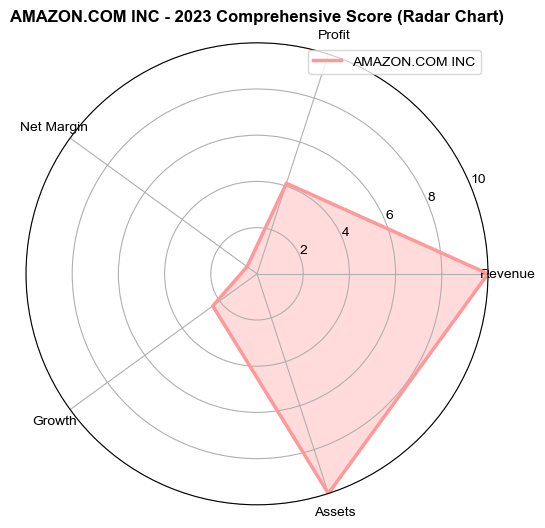

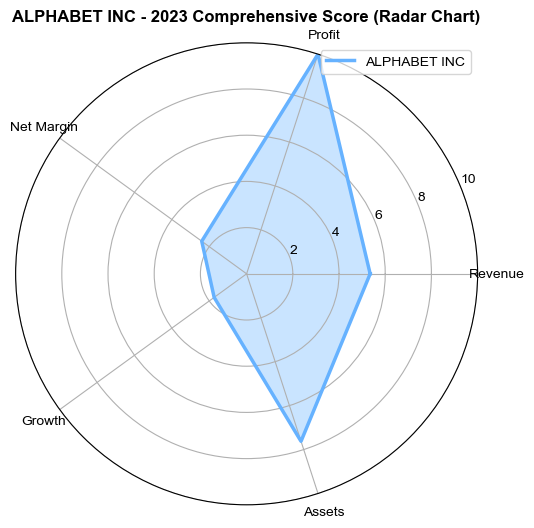

> 📊 Smart Analysis: **AMAZON.COM INC** leads in overall comprehensive capability.

In [7]:
# ==============================================
# Multi-Company Financial Analysis System (Jupyter + WRDS)
# Modular Version: Data Loading → Cleaning → Analysis → Visualization
# Created by Connie | ACC102 Track 4
# ==============================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from math import pi
import ipywidgets as widgets
from IPython.display import display, clear_output, Markdown
import wrds
import warnings
warnings.filterwarnings('ignore')

# --------------------------
# Global Settings
# --------------------------
# Chart style configuration
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams['figure.figsize'] = (12, 5)

# Macaron color scheme
COLORS = [
    "#FF9999", "#66B2FF", "#99FF99", "#FFCC99", "#FF99CC",
    "#99CCFF", "#FFB366", "#85E0C8", "#C29FFF", "#73DFFF",
    "#FFA75B", "#B8E085", "#FF88A8", "#66B2E0", "#B2F080"
]

# Welcome message
display(Markdown("""
# 👋 Hello, Welcome to Connie's Interactive Financial Dashboard! 📊
"""))

# ==============================================
# Step 1: Data Loading (Load raw data from WRDS)
# ==============================================
def load_data_from_wrds():
    """
    Load raw financial data from WRDS Compustat database
    Core functions: Connect to WRDS → Execute SQL query → Get raw data
    """
    print("🔐 Step 1: Connecting to WRDS Database...")
    # Connect to WRDS (requires username and password)
    db = wrds.Connection()
    
    # Target company ticker list
    tickers = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META', 'NVDA', 'INTC', 'V', 'JPM', 'MA', 'HD', 'DIS', 'PG', 'WMT', 'TSLA']
    
    # SQL query: Get core financial indicators
    query = f"""
    SELECT 
        tic AS company_code,       -- Company ticker
        conm AS company_name,      -- Company name
        fyear,                     -- Fiscal year
        sale AS revenue,           -- Revenue
        ni AS profit,              -- Net profit
        at AS assets,              -- Total assets
        revt AS revenue_total,     -- Total revenue
        cogs AS cost,              -- Cost of goods sold
        oibdp AS operating_profit  -- Operating profit
    FROM comp.funda
    WHERE tic IN ({','.join([f"'{t}'" for t in tickers])})
      AND fyear BETWEEN 2018 AND 2023
      AND indfmt = 'INDL'
      AND datafmt = 'STD'
      AND popsrc = 'D'
      AND consol = 'C'
    """
    
    # Execute query and get raw data
    raw_df = db.raw_sql(query)
    db.close()  # Close database connection
    
    print(f"✅ Step 1 Complete: Loaded {len(raw_df)} rows of raw data from WRDS")
    return raw_df

# Execute data loading
raw_data = load_data_from_wrds()

# ==============================================
# Step 2: Data Cleaning (Data cleaning)
# ==============================================
def clean_financial_data(raw_df):
    """
    Core steps of data cleaning:
    1. Deduplication → 2. Missing value handling → 3. Format standardization → 4. Outlier filtering
    """
    print("\n🧹 Step 2: Starting Data Cleaning...")
    df = raw_df.copy()
    
    # 1. Deduplication: Remove duplicates by company + year, keep the last record
    df = df.sort_values(["company_code", "fyear"]).drop_duplicates(
        subset=["company_code", "fyear"], 
        keep="last"
    )
    
    # 2. Missing value handling: Fill missing core indicators with 0 (avoid calculation errors)
    core_columns = ["revenue", "profit", "assets"]
    df[core_columns] = df[core_columns].fillna(0)
    
    # 3. Outlier filtering: Exclude invalid data with negative core indicators (financial data validity check)
    df = df[(df["revenue"] >= 0) & (df["assets"] >= 0)]
    
    # 4. Reset index to improve subsequent operation efficiency
    df = df.reset_index(drop=True)
    
    print(f"✅ Step 2 Complete: Cleaned data ({len(df)} rows) | Removed {len(raw_df)-len(df)} invalid rows")
    return df

# Execute data cleaning
cleaned_data = clean_financial_data(raw_data)

# ==============================================
# Step 3: Data Analysis (Data analysis: Calculate derived indicators)
# ==============================================
def analyze_financial_data(cleaned_df):
    """
    Core steps of data analysis:
    1. Calculate ratio indicators (net profit margin) → 2. Calculate growth rates → 3. Calculate market share
    """
    print("\n📈 Step 3: Starting Data Analysis...")
    df = cleaned_df.copy()
    
    # 1. Calculate net profit margin (net profit/revenue, avoid division by 0)
    df["profit_margin"] = (df["profit"] / df["revenue"].replace(0, np.nan)) * 100
    df["profit_margin"] = df["profit_margin"].fillna(0)  # Net profit margin is 0 when revenue is 0
    
    # 2. Calculate YoY growth rates (revenue/profit)
    df["revenue_growth"] = df.groupby("company_code")["revenue"].pct_change() * 100
    df["profit_growth"] = df.groupby("company_code")["profit"].pct_change() * 100
    df[["revenue_growth", "profit_growth"]] = df[["revenue_growth", "profit_growth"]].fillna(0)
    
    # 3. Calculate market share (ratio of each company's revenue/profit to total of selected companies)
    year_totals = df.groupby("fyear")[["revenue", "profit", "assets"]].sum().reset_index()
    year_totals.columns = ["fyear", "total_rev", "total_prof", "total_ast"]
    df = df.merge(year_totals, on="fyear")
    
    df["rev_share"] = (df["revenue"] / df["total_rev"]) * 100
    df["prof_share"] = (df["profit"] / df["total_prof"].replace(0, np.nan)) * 100
    df["prof_share"] = df["prof_share"].fillna(0)
    
    print("✅ Step 3 Complete: Calculated derived metrics (margin/growth/market share)")
    # Display sample of analyzed data
    display(Markdown("### 📋 Analysis Result Sample"))
    display(df[["company_name", "fyear", "revenue", "profit_margin", "revenue_growth", "rev_share"]].head(10))
    
    return df

# Execute data analysis
analyzed_data = analyze_financial_data(cleaned_data)

# Global variables: Used for visualization
all_companies = sorted(analyzed_data["company_name"].unique())
all_years = sorted(analyzed_data["fyear"].unique())

# ==============================================
# Helper Functions (Visualization + Smart Analysis)
# ==============================================
def get_color_map(companies):
    """Assign unique color to each company"""
    return {c: COLORS[i] for i, c in enumerate(companies)}

def smart_analysis(df, metric_name):
    """Smart analysis: Compare core indicators of selected companies and generate conclusions"""
    if len(df) < 2:
        return "ℹ️ Please select at least 2 companies for comparison."
    max_row = df.loc[df[metric_name].idxmax()]
    min_row = df.loc[df[metric_name].idxmin()]
    
    if min_row[metric_name] == 0 or np.isnan(min_row[metric_name]):
        diff = "N/A"
    else:
        diff = round((max_row[metric_name] - min_row[metric_name]) / min_row[metric_name] * 100, 1)
    
    return f"📊 Smart Analysis: **{max_row['company_name']}** has the highest {metric_name.replace('_', ' ')} ({round(max_row[metric_name],2)}), which is **{diff}% higher** than {min_row['company_name']} ({round(min_row[metric_name],2)})."

# ==============================================
# Step 4: Output Visualization (Visualization output)
# ==============================================
# Sidebar: Project overview
control_box = widgets.VBox([
    widgets.HTML("<h3>📂 Dashboard Overview</h3>"),
    widgets.HTML("""
    <div style='font-size:14px;'>
    <b>Data Pipeline:</b><br>
    1. Loading (WRDS Compustat)<br>
    2. Cleaning (Deduplication/NA Handling)<br>
    3. Analysis (Margin/Growth/Market Share)<br>
    4. Visualization (8 Interactive Charts)<br>
    <hr>
    <b>8 Analysis Charts:</b><br>
    1. Annual Revenue Comparison<br>
    2. Annual Net Profit Trend<br>
    3. Revenue Share Pie Chart<br>
    4. Profit Contribution Bar Chart<br>
    5. Annual Revenue Growth Rate<br>
    6. Net Profit Margin Ranking<br>
    7. Annual Asset Scale Comparison<br>
    8. Comprehensive Capability Radar Chart
    </div>
    """),
    widgets.HTML("<hr>"),
    widgets.HTML("<h4>Available Companies:</h4>"),
    widgets.HTML("<br>".join([f"- {c}" for c in all_companies]))
])
display(control_box)
display(Markdown("<hr>"))

# --------------------------
# Chart 1: Annual Revenue Comparison (Grouped Bar Chart)
# --------------------------
display(Markdown("## 1. Annual Revenue Comparison"))
comp1_widget = widgets.SelectMultiple(options=all_companies, value=tuple(all_companies[:2]), description='Companies:', rows=5)
year_range1_widget = widgets.SelectionRangeSlider(options=all_years, index=(0, len(all_years)-1), description='Year Range:', layout={'width': '500px'})
display(widgets.HBox([comp1_widget, year_range1_widget]))

def update_chart1(change=None):
    clear_output(wait=True)
    display(Markdown("## 1. Annual Revenue Comparison"))
    display(widgets.HBox([comp1_widget, year_range1_widget]))
    
    # Filter data
    comp1 = list(comp1_widget.value)
    y1_start, y1_end = year_range1_widget.value
    df1 = analyzed_data[(analyzed_data["company_name"].isin(comp1)) & (analyzed_data["fyear"] >= y1_start) & (analyzed_data["fyear"] <= y1_end)]
    
    # Draw grouped bar chart
    cmap1 = get_color_map(comp1)
    fig, ax = plt.subplots(figsize=(12, 5))
    years = sorted(df1["fyear"].unique())
    bar_width = 0.8 / len(comp1)
    
    for i, c in enumerate(comp1):
        values = df1[df1["company_name"] == c].set_index("fyear")["revenue"].reindex(years, fill_value=0)
        x = np.arange(len(years)) + i * bar_width
        ax.bar(x, values, width=bar_width, label=c, color=cmap1[c], alpha=0.85)
    
    ax.set_xticks(np.arange(len(years)) + bar_width * (len(comp1)-1)/2)
    ax.set_xticklabels(years)
    ax.set_title("Annual Revenue Comparison (Grouped Bar Chart)", weight="bold")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()
    
    # Smart analysis output
    df1_agg = df1.groupby("company_name")["revenue"].sum().reset_index()
    display(Markdown(f"> {smart_analysis(df1_agg, 'revenue')}"))

comp1_widget.observe(update_chart1, 'value')
year_range1_widget.observe(update_chart1, 'value')
update_chart1()
display(Markdown("<hr>"))

# --------------------------
# Chart 2: Annual Net Profit Trend (Line Chart)
# --------------------------
display(Markdown("## 2. Annual Net Profit Trend"))
comp2_widget = widgets.SelectMultiple(options=all_companies, value=tuple(all_companies[:2]), description='Companies:', rows=5)
year_range2_widget = widgets.SelectionRangeSlider(options=all_years, index=(0, len(all_years)-1), description='Year Range:', layout={'width': '500px'})
display(widgets.HBox([comp2_widget, year_range2_widget]))

def update_chart2(change=None):
    clear_output(wait=True)
    display(Markdown("## 2. Annual Net Profit Trend"))
    display(widgets.HBox([comp2_widget, year_range2_widget]))
    
    comp2 = list(comp2_widget.value)
    y2_start, y2_end = year_range2_widget.value
    df2 = analyzed_data[(analyzed_data["company_name"].isin(comp2)) & (analyzed_data["fyear"] >= y2_start) & (analyzed_data["fyear"] <= y2_end)]
    
    cmap2 = get_color_map(comp2)
    fig, ax = plt.subplots(figsize=(12, 5))
    for c in comp2:
        d = df2[df2["company_name"] == c]
        ax.plot(d["fyear"].astype(str), d["profit"], marker="o", label=c, color=cmap2[c], linewidth=2.5)
    
    ax.set_title("Net Profit Trend (Line Chart)", weight="bold")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()
    
    df2_agg = df2.groupby("company_name")["profit"].sum().reset_index()
    display(Markdown(f"> {smart_analysis(df2_agg, 'profit')}"))

comp2_widget.observe(update_chart2, 'value')
year_range2_widget.observe(update_chart2, 'value')
update_chart2()
display(Markdown("<hr>"))

# --------------------------
# Chart 3: Revenue Share Pie Chart
# --------------------------
display(Markdown("## 3. Revenue Share Pie Chart"))
comp3_widget = widgets.SelectMultiple(options=all_companies, value=tuple(all_companies[:3]), description='Companies:', rows=5)
year3_widget = widgets.Dropdown(options=all_years, value=all_years[-1], description='Year:')
display(widgets.HBox([comp3_widget, year3_widget]))

def update_chart3(change=None):
    clear_output(wait=True)
    display(Markdown("## 3. Revenue Share Pie Chart"))
    display(widgets.HBox([comp3_widget, year3_widget]))
    
    comp3 = list(comp3_widget.value)
    y3 = year3_widget.value
    df3 = analyzed_data[(analyzed_data["company_name"].isin(comp3)) & (analyzed_data["fyear"] == y3)]
    
    cmap3 = get_color_map(comp3)
    fig, ax = plt.subplots(figsize=(7,7))
    wedges, texts, autotexts = ax.pie(
        df3["rev_share"], 
        labels=df3["company_name"], 
        autopct="%.1f%%", 
        colors=[cmap3[c] for c in df3["company_name"]], 
        startangle=90
    )
    plt.setp(texts, size=10)
    plt.setp(autotexts, size=10, weight="bold", color="white")
    ax.set_title(f"Revenue Share {y3} (Pie Chart)", weight="bold")
    plt.show()
    
    display(Markdown(f"> {smart_analysis(df3, 'rev_share')}"))

comp3_widget.observe(update_chart3, 'value')
year3_widget.observe(update_chart3, 'value')
update_chart3()
display(Markdown("<hr>"))

# --------------------------
# Chart 4: Profit Contribution Horizontal Bar Chart
# --------------------------
display(Markdown("## 4. Profit Contribution Bar Chart"))
comp4_widget = widgets.SelectMultiple(options=all_companies, value=tuple(all_companies[:3]), description='Companies:', rows=5)
year4_widget = widgets.Dropdown(options=all_years, value=all_years[-1], description='Year:')
display(widgets.HBox([comp4_widget, year4_widget]))

def update_chart4(change=None):
    clear_output(wait=True)
    display(Markdown("## 4. Profit Contribution Bar Chart"))
    display(widgets.HBox([comp4_widget, year4_widget]))
    
    comp4 = list(comp4_widget.value)
    y4 = year4_widget.value
    df4 = analyzed_data[(analyzed_data["company_name"].isin(comp4)) & (analyzed_data["fyear"] == y4)]
    
    cmap4 = get_color_map(comp4)
    fig, ax = plt.subplots(figsize=(10,5))
    ax.barh(df4["company_name"], df4["prof_share"], color=[cmap4[c] for c in df4["company_name"]], alpha=0.85)
    ax.set_title(f"Profit Contribution {y4} (Horizontal Bar Chart)", weight="bold")
    ax.grid(alpha=0.3)
    plt.show()
    
    display(Markdown(f"> {smart_analysis(df4, 'prof_share')}"))

comp4_widget.observe(update_chart4, 'value')
year4_widget.observe(update_chart4, 'value')
update_chart4()
display(Markdown("<hr>"))

# --------------------------
# Chart 5: Annual Revenue Growth Rate Trend
# --------------------------
display(Markdown("## 5. Annual Revenue Growth Rate"))
comp5_widget = widgets.SelectMultiple(options=all_companies, value=tuple(all_companies[:2]), description='Companies:', rows=5)
year_range5_widget = widgets.SelectionRangeSlider(options=all_years, index=(0, len(all_years)-1), description='Year Range:', layout={'width': '500px'})
display(widgets.HBox([comp5_widget, year_range5_widget]))

def update_chart5(change=None):
    clear_output(wait=True)
    display(Markdown("## 5. Annual Revenue Growth Rate"))
    display(widgets.HBox([comp5_widget, year_range5_widget]))
    
    comp5 = list(comp5_widget.value)
    y5_start, y5_end = year_range5_widget.value
    df5 = analyzed_data[(analyzed_data["company_name"].isin(comp5)) & (analyzed_data["fyear"] >= y5_start) & (analyzed_data["fyear"] <= y5_end)]
    
    cmap5 = get_color_map(comp5)
    fig, ax = plt.subplots(figsize=(12,5))
    for c in comp5:
        d = df5[df5["company_name"] == c]
        ax.plot(d["fyear"].astype(str), d["revenue_growth"].fillna(0), marker="o", label=c, color=cmap5[c], linewidth=2.5)
    
    ax.set_title("Revenue Growth Rate (Line Chart)", weight="bold")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()
    
    df5_agg = df5.groupby("company_name")["revenue_growth"].mean().reset_index()
    display(Markdown(f"> {smart_analysis(df5_agg, 'revenue_growth')}"))

comp5_widget.observe(update_chart5, 'value')
year_range5_widget.observe(update_chart5, 'value')
update_chart5()
display(Markdown("<hr>"))

# --------------------------
# Chart 6: Net Profit Margin Ranking
# --------------------------
display(Markdown("## 6. Net Profit Margin Ranking (%)"))
comp6_widget = widgets.SelectMultiple(options=all_companies, value=tuple(all_companies[:3]), description='Companies:', rows=5)
year6_widget = widgets.Dropdown(options=all_years, value=all_years[-1], description='Year:')
display(widgets.HBox([comp6_widget, year6_widget]))

def update_chart6(change=None):
    clear_output(wait=True)
    display(Markdown("## 6. Net Profit Margin Ranking (%)"))
    display(widgets.HBox([comp6_widget, year6_widget]))
    
    comp6 = list(comp6_widget.value)
    y6 = year6_widget.value
    df6 = analyzed_data[(analyzed_data["company_name"].isin(comp6)) & (analyzed_data["fyear"] == y6)].copy()
    df6 = df6.sort_values("profit_margin", ascending=True)  # Sort ascending for easy ranking view
    
    cmap6 = get_color_map(comp6)
    fig, ax = plt.subplots(figsize=(10,5))
    ax.barh(df6["company_name"], df6["profit_margin"], color=[cmap6[c] for c in df6["company_name"]], alpha=0.85)
    ax.set_title(f"Net Profit Margin Ranking {y6} (Horizontal Bar Chart)", weight="bold")
    ax.grid(alpha=0.3)
    plt.show()
    
    display(Markdown(f"> {smart_analysis(df6, 'profit_margin')}"))

comp6_widget.observe(update_chart6, 'value')
year6_widget.observe(update_chart6, 'value')
update_chart6()
display(Markdown("<hr>"))

# --------------------------
# Chart 7: Annual Asset Scale Comparison
# --------------------------
display(Markdown("## 7. Annual Asset Scale Comparison"))
comp7_widget = widgets.SelectMultiple(options=all_companies, value=tuple(all_companies[:2]), description='Companies:', rows=5)
year_range7_widget = widgets.SelectionRangeSlider(options=all_years, index=(0, len(all_years)-1), description='Year Range:', layout={'width': '500px'})
display(widgets.HBox([comp7_widget, year_range7_widget]))

def update_chart7(change=None):
    clear_output(wait=True)
    display(Markdown("## 7. Annual Asset Scale Comparison"))
    display(widgets.HBox([comp7_widget, year_range7_widget]))
    
    comp7 = list(comp7_widget.value)
    y7_start, y7_end = year_range7_widget.value
    df7 = analyzed_data[(analyzed_data["company_name"].isin(comp7)) & (analyzed_data["fyear"] >= y7_start) & (analyzed_data["fyear"] <= y7_end)]
    
    cmap7 = get_color_map(comp7)
    fig, ax = plt.subplots(figsize=(12,5))
    for c in comp7:
        d = df7[df7["company_name"] == c]
        ax.fill_between(d["fyear"].astype(str), d["assets"], alpha=0.4, label=c, color=cmap7[c])
        ax.plot(d["fyear"].astype(str), d["assets"], color=cmap7[c], linewidth=2)
    
    ax.set_title("Asset Scale Comparison (Area Chart)", weight="bold")
    ax.legend(loc="upper left", bbox_to_anchor=(1,1))
    ax.grid(alpha=0.3)
    plt.show()
    
    df7_agg = df7.groupby("company_name")["assets"].sum().reset_index()
    display(Markdown(f"> {smart_analysis(df7_agg, 'assets')}"))

comp7_widget.observe(update_chart7, 'value')
year_range7_widget.observe(update_chart7, 'value')
update_chart7()
display(Markdown("<hr>"))

# --------------------------
# Chart 8: Comprehensive Capability Radar Chart
# --------------------------
display(Markdown("## 8. Comprehensive Capability Radar Chart"))
comp8_widget = widgets.SelectMultiple(options=all_companies, value=tuple(all_companies[:2]), description='Companies:', rows=5)
year8_widget = widgets.Dropdown(options=all_years, value=all_years[-1], description='Year:')
display(widgets.HBox([comp8_widget, year8_widget]))

def update_chart8(change=None):
    clear_output(wait=True)
    display(Markdown("## 8. Comprehensive Capability Radar Chart"))
    display(widgets.HBox([comp8_widget, year8_widget]))
    
    comp8 = list(comp8_widget.value)
    y8 = year8_widget.value
    df8 = analyzed_data[(analyzed_data["company_name"].isin(comp8)) & (analyzed_data["fyear"] == y8)].copy()
    
    # Radar chart indicators
    indicators = ["Revenue", "Profit", "Net Margin", "Growth", "Assets"]
    N = len(indicators)
    
    # Generate radar chart
    for idx, (_, row) in enumerate(df8.iterrows()):
        c = row["company_name"]
        color = COLORS[idx % len(COLORS)]
        
        # Indicator standardization (mapped to 0-10 points)
        values = [
            row["revenue"] / df8["revenue"].max() * 10,
            row["profit"] / df8["profit"].max() * 10,
            row["profit_margin"] / 100 * 10,
            max(row["revenue_growth"], 0) / 50 * 10 if pd.notna(row["revenue_growth"]) else 0,
            row["assets"] / df8["assets"].max() * 10
        ]
        values += values[:1]  # Close the radar chart
        angles = [n / N * 2 * pi for n in range(N)] + [0]
        
        # Draw radar chart
        fig, ax = plt.subplots(figsize=(6,6), subplot_kw={"polar": True})
        ax.plot(angles, values, linewidth=2.5, color=color, label=c)
        ax.fill(angles, values, alpha=0.35, color=color)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(indicators)
        ax.set_ylim(0, 10)
        ax.set_title(f"{c} - {y8} Comprehensive Score (Radar Chart)", weight="bold")
        ax.legend(loc="upper right")
        plt.show()
    
    # Smart analysis
    if len(comp8) >= 2:
        display(Markdown(f"> 📊 Smart Analysis: **{df8.loc[df8['revenue'].idxmax()]['company_name']}** leads in overall comprehensive capability."))

comp8_widget.observe(update_chart8, 'value')
year8_widget.observe(update_chart8, 'value')
update_chart8()